In [1]:
!pip install scikit-posthocs

In [2]:
#Bibliotecas

import pandas as pd
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import scikit_posthocs as sp


df = pd.read_csv(
    "Trabalho_Ergonomia(DADOS).csv",
    sep=";",
    encoding="latin1",
    decimal=","
)

Meu dados :

Local

Medição (µT)

a comparação descritiva deve ser feita entre os locais, observando para cada grupo:

quantidade de observações

média

mediana

desvio padrão

variância

mínimo

máximo

amplitude

coeficiente de variação

Depois, refazemos tudo sem os valores discrepantes, para ver como a distribuição muda.

**Vou usar o critério mais comum: IQR (Intervalo Interquartil) dentro de cada grupo.**

**Um valor é considerado discrepante se:**

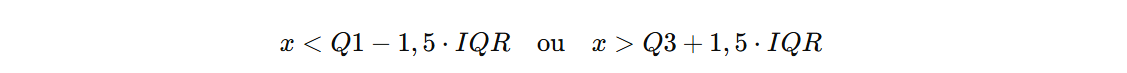

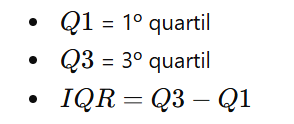

Isso é importante porque os outliers serão removidos dentro de cada Local, e não no conjunto inteiro.

In [3]:
coluna_valor = "Medição  (µT)"
coluna_grupo = "Local"


# Análise descritiva e comparativa com todos os dados

analise_completa = df.groupby(coluna_grupo)[coluna_valor].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    var="var",
    min="min",
    max="max"
)

analise_completa["amplitude"] = analise_completa["max"] - analise_completa["min"]
analise_completa["cv_%"] = (analise_completa["std"] / analise_completa["mean"]) * 100

# Ordenar pela média
analise_completa = analise_completa.sort_values(by="mean", ascending=False)

print("\nANÁLISE 1 — COM TODOS OS DADOS")
print(analise_completa.round(4))


#Função para remover outliers por grupo usando IQR
def remover_outliers_iqr(grupo):
    q1 = grupo[coluna_valor].quantile(0.25)
    q3 = grupo[coluna_valor].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    grupo_filtrado = grupo[
        (grupo[coluna_valor] >= limite_inferior) &
        (grupo[coluna_valor] <= limite_superior)
    ]
    return grupo_filtrado


#Remover outliers por Local

df_sem_outliers = df.groupby(coluna_grupo, group_keys=False).apply(remover_outliers_iqr)

#Análise descritiva e comparativa sem outliers

analise_sem_outliers = df_sem_outliers.groupby(coluna_grupo)[coluna_valor].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    var="var",
    min="min",
    max="max"
)

analise_sem_outliers["amplitude"] = analise_sem_outliers["max"] - analise_sem_outliers["min"]
analise_sem_outliers["cv_%"] = (analise_sem_outliers["std"] / analise_sem_outliers["mean"]) * 100

# Ordenar pela média
analise_sem_outliers = analise_sem_outliers.sort_values(by="mean", ascending=False)

print("\nANÁLISE 2 — SEM VALORES DISCREPANTES")
print(analise_sem_outliers.round(4))

#Quantidade removida por grupo
total_por_grupo = df.groupby(coluna_grupo)[coluna_valor].count()
total_sem_outliers = df_sem_outliers.groupby(coluna_grupo)[coluna_valor].count()

comparacao_remocao = pd.DataFrame({
    "n_total": total_por_grupo,
    "n_sem_outliers": total_sem_outliers
})

comparacao_remocao["outliers_removidos"] = (
    comparacao_remocao["n_total"] - comparacao_remocao["n_sem_outliers"]
)

comparacao_remocao["pct_removido_%"] = (
    comparacao_remocao["outliers_removidos"] / comparacao_remocao["n_total"] * 100
)

comparacao_remocao = comparacao_remocao.sort_values(
    by="outliers_removidos",
    ascending=False
)

print("\nQUANTIDADE DE VALORES DISCREPANTES REMOVIDOS POR GRUPO")
print(comparacao_remocao.round(4))


ANÁLISE 1 — COM TODOS OS DADOS
          count    mean  median     std      var     min      max  amplitude  \
Local                                                                          
PT9CTBC    9832  6.5812  6.3455  3.2629  10.6462  1.2544  15.2822    14.0278   
PT10BE12  22697  1.5268  1.4231  0.3298   0.1088  0.9224   2.4221     1.4998   
PT6CB3    22073  1.3498  1.2915  0.2152   0.0463  0.9758   2.0314     1.0556   
PT5A3     26601  1.2195  1.1767  0.1174   0.0138  1.0743   1.5266     0.4523   
PT11J1     7429  1.1858  1.1823  0.0540   0.0029  1.0079   1.4479     0.4400   
PT2B7      3849  1.1796  1.1743  0.0569   0.0032  1.0233   1.6003     0.5770   
PT1M4      4904  1.1741  1.1385  0.1272   0.0162  0.2576   1.8130     1.5554   
PT7JO3     9812  1.1666  1.1677  0.0379   0.0014  1.0445   1.2843     0.2398   
PT4A2     12821  1.1382  1.1306  0.0582   0.0034  0.9574   1.4697     0.5123   
PT3MM15   14481  1.1299  1.1381  0.0424   0.0018  0.9757   1.3937     0.4179   
PT8BM16 

/tmp/ipykernel_37510/1935705285.py:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sem_outliers = df.groupby(coluna_grupo, group_keys=False).apply(remover_outliers_iqr)


<Figure size 1200x600 with 0 Axes>

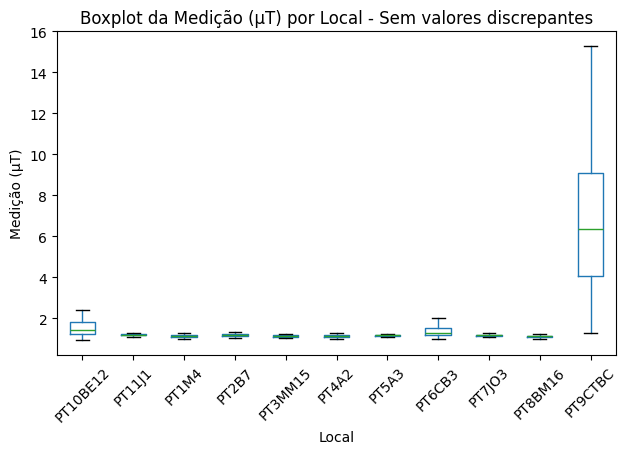

In [4]:
plt.figure(figsize=(12, 6))
df_sem_outliers.boxplot(column=coluna_valor, by=coluna_grupo, grid=False, showfliers=False)
plt.title("Boxplot da Medição (µT) por Local - Sem valores discrepantes")
plt.suptitle("")
plt.xlabel("Local")
plt.ylabel("Medição (µT)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**REMOVENDO O PT9CTBC**

/tmp/ipykernel_37510/2998577062.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sem_outliers = df.groupby(coluna_grupo, group_keys=False).apply(remover_outliers_iqr)


<Figure size 1200x600 with 0 Axes>

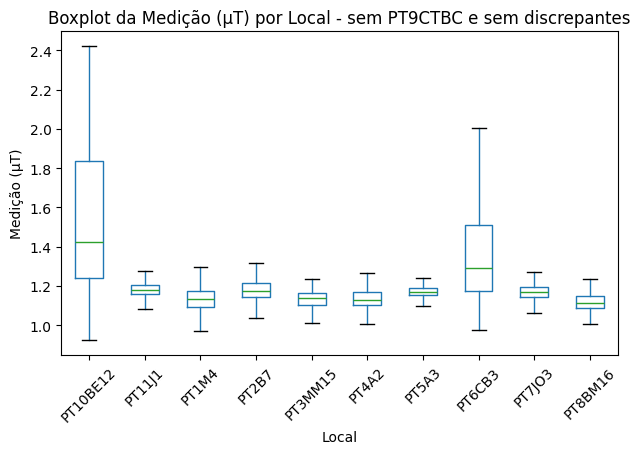

In [9]:
# Remover PT9CTBC
df = df[df["Local"] != "PT9CTBC"]

# Função para remover outliers por grupo
def remover_outliers_iqr(grupo):
    q1 = grupo[coluna_valor].quantile(0.25)
    q3 = grupo[coluna_valor].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    return grupo[
        (grupo[coluna_valor] >= limite_inferior) &
        (grupo[coluna_valor] <= limite_superior)
    ]

# Remover outliers por grupo
df_sem_outliers = df.groupby(coluna_grupo, group_keys=False).apply(remover_outliers_iqr)

# Boxplot
plt.figure(figsize=(12, 6))
df_sem_outliers.boxplot(
    column=coluna_valor,
    by=coluna_grupo,
    grid=False,
    showfliers=False
)

plt.title("Boxplot da Medição (µT) por Local - sem PT9CTBC e sem discrepantes")
plt.suptitle("")
plt.xlabel("Local")
plt.ylabel("Medição (µT)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Ordenado os locais pela mediana**

Uma maneira melhor para visualizar o boxplot

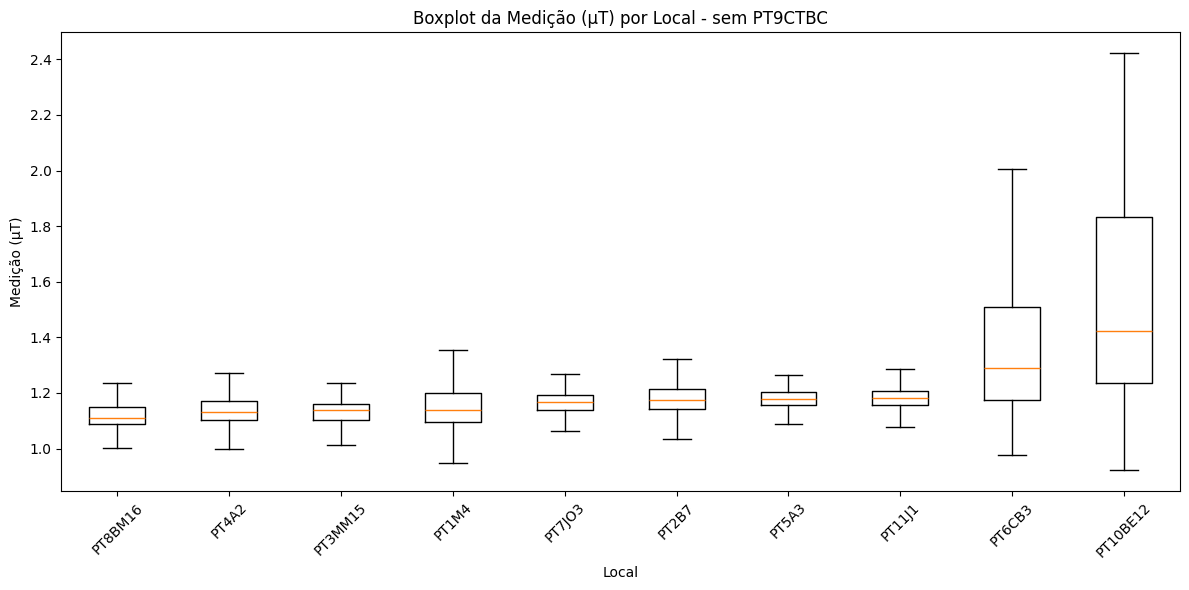

In [10]:
# Remover PT9CTBC
df_filtrado = df[df["Local"] != "PT9CTBC"]

# Ordenar os locais pela mediana
ordem = df_filtrado.groupby("Local")["Medição  (µT)"].median().sort_values().index

# Preparar dados
dados_ordenados = [
    df_filtrado[df_filtrado["Local"] == local]["Medição  (µT)"]
    for local in ordem
]

# Plotar boxplot
plt.figure(figsize=(12, 6))
plt.boxplot(dados_ordenados, tick_labels=ordem, showfliers=False)

plt.title("Boxplot da Medição (µT) por Local - sem PT9CTBC")
plt.xlabel("Local")
plt.ylabel("Medição (µT)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

count → quantidade de valores existentes na coluna
Ex.: se uma coluna tem 20 números preenchidos, então count = 20

mean → média aritmética dos valores
Fórmula: soma dos valores ÷ quantidade

std → desvio padrão
Mostra o quanto os valores estão espalhados em relação à média.
Quanto maior o std, mais dispersos os dados estão.

min → menor valor da coluna

max → maior valor da coluna

**Aplicando o teste de Kruskal-Wallis (Sem os valores dicrepantes)**

In [21]:
#Função para remover valores discrepantes por grupo usando IQR
def remover_outliers_iqr(grupo):
    q1 = grupo[coluna_valor].quantile(0.25)
    q3 = grupo[coluna_valor].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    grupo_filtrado = grupo[
        (grupo[coluna_valor] >= limite_inferior) &
        (grupo[coluna_valor] <= limite_superior)
    ]
    return grupo_filtrado


#Remover outliers por grupo

df_sem_outliers = df.groupby(coluna_grupo, group_keys=False).apply(remover_outliers_iqr)


#Separar os grupos para o teste

grupos = [
    grupo[coluna_valor].dropna().values
    for _, grupo in df_sem_outliers.groupby(coluna_grupo)
]

#Aplicar o teste de Kruskal-Wallis

estatistica, p_valor = kruskal(*grupos)


#Exibir resultados com 4 casas decimais

print("Teste de Kruskal-Wallis sem valores discrepantes")
print(f"Estatística H = {estatistica:.4f}")
print(f"p-valor = {p_valor:.4f}")

if p_valor < 0.05:
    print("Conclusão: há diferença estatisticamente significativa entre os grupos.")
else:
    print("Conclusão: não há diferença estatisticamente significativa entre os grupos.")

Teste de Kruskal-Wallis sem valores discrepantes
Estatística H = 48463.2692
p-valor = 0.0000
Conclusão: há diferença estatisticamente significativa entre os grupos.


/tmp/ipykernel_37510/75905249.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sem_outliers = df.groupby(coluna_grupo, group_keys=False).apply(remover_outliers_iqr)


**Como p < 0,05, rejeitamos a hipótese nula.**

**Isso indica que, mesmo após remover os valores discrepantes, ainda existem diferenças estatisticamente significativas entre os grupos (Local) em relação à variável Medição (µT).**

**Gráfico Para o teste de Kruskal Wallis**

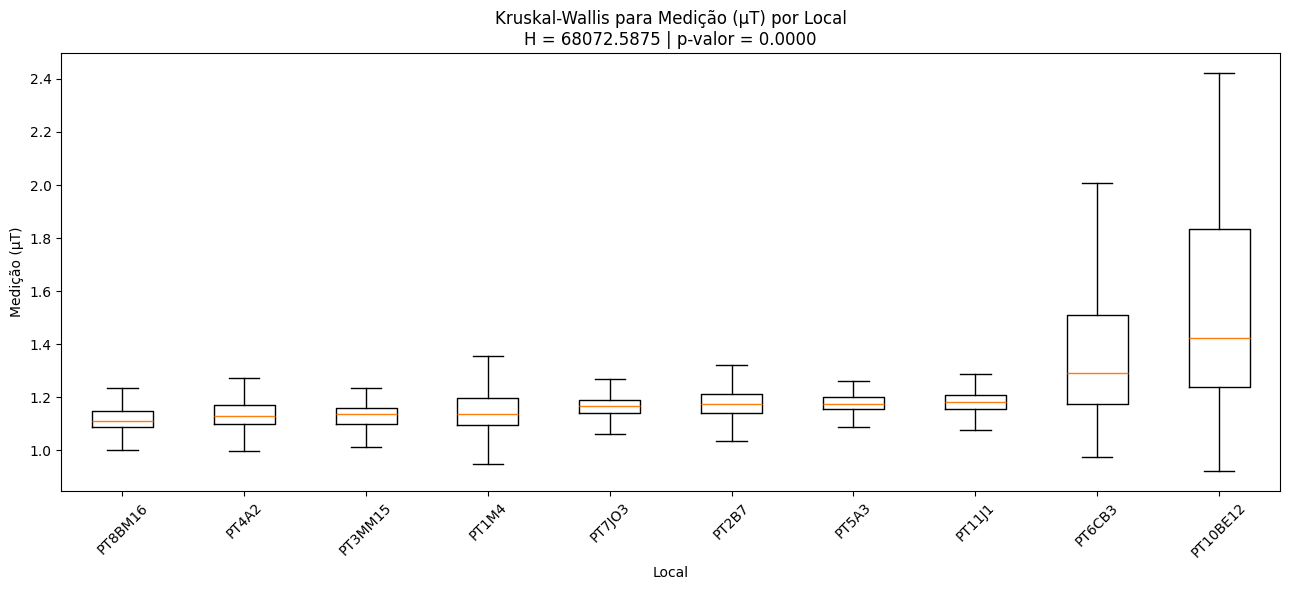

In [11]:
plt.figure(figsize=(13, 6))
plt.boxplot(dados_ordenados, tick_labels=ordem, showfliers=False)

plt.title(
    f"Kruskal-Wallis para Medição (µT) por Local\n"
    f"H = {estatistica:.4f} | p-valor = {p_valor:.4f}"
)
plt.xlabel("Local")
plt.ylabel("Medição (µT)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Pós-teste Dunn

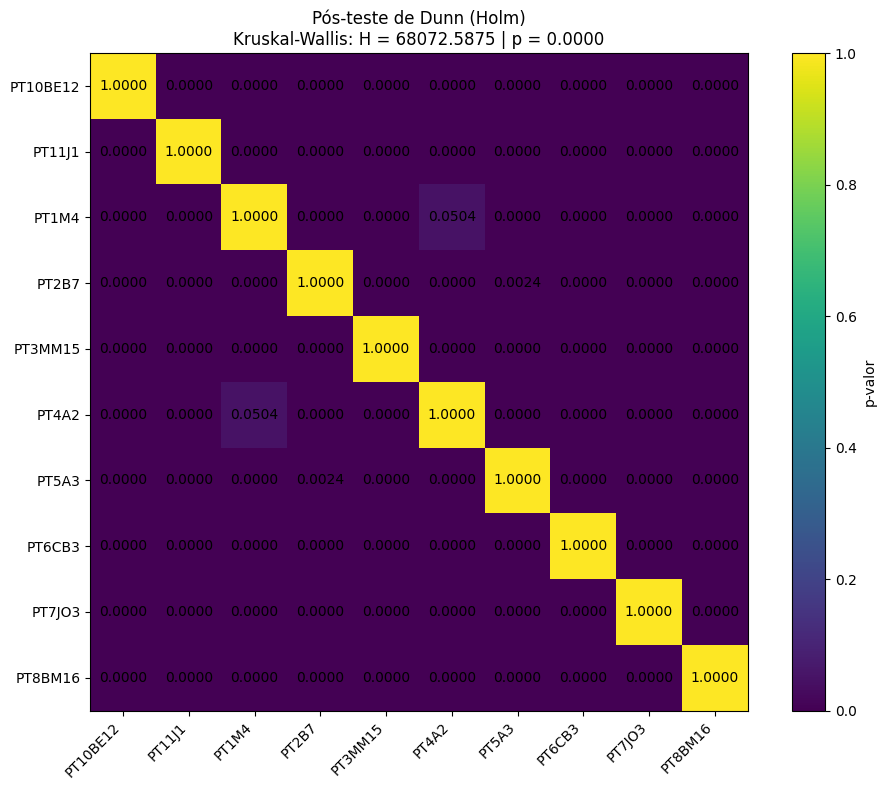

In [17]:
import numpy as np

#Pós-teste de Dunn
dunn = sp.posthoc_dunn(
    df_sem_outliers,
    val_col=coluna_valor,
    group_col=coluna_grupo,
    p_adjust="holm"
)


#Listar pares significativos e não significativos
pares_significativos = []
pares_nao_significativos = []

matriz = dunn.values

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz)

# Nomes dos grupos
ax.set_xticks(np.arange(len(dunn.columns)))
ax.set_yticks(np.arange(len(dunn.index)))
ax.set_xticklabels(dunn.columns, rotation=45, ha="right")
ax.set_yticklabels(dunn.index)

# Escrever os valores dentro das células
for i in range(len(dunn.index)):
    for j in range(len(dunn.columns)):
        ax.text(j, i, f"{matriz[i, j]:.4f}", ha="center", va="center")

plt.title(
    f"Pós-teste de Dunn (Holm)\n"
    f"Kruskal-Wallis: H = {estatistica:.4f} | p = {p_valor:.4f}"
)
plt.colorbar(im, label="p-valor")
plt.tight_layout()
plt.show()


In [19]:
locais = dunn.index.tolist()

for i in range(len(locais)):
    for j in range(i + 1, len(locais)):
        grupo1 = locais[i]
        grupo2 = locais[j]
        p = dunn.loc[grupo1, grupo2]

        if p < 0.05:
            pares_significativos.append((grupo1, grupo2, p))
        else:
            pares_nao_significativos.append((grupo1, grupo2, p))

#print("\nPares com diferença significativa:")
#for g1, g2, p in pares_significativos:
    #print(f"{g1} vs {g2} -> p = {p:.4f}")

print("\nPares sem diferença significativa:")
for g1, g2, p in pares_nao_significativos:
    print(f"{g1} vs {g2} -> p = {p:.4f}")


Pares sem diferença significativa:
PT1M4 vs PT4A2 -> p = 0.0504
PT1M4 vs PT4A2 -> p = 0.0504
PT1M4 vs PT4A2 -> p = 0.0504


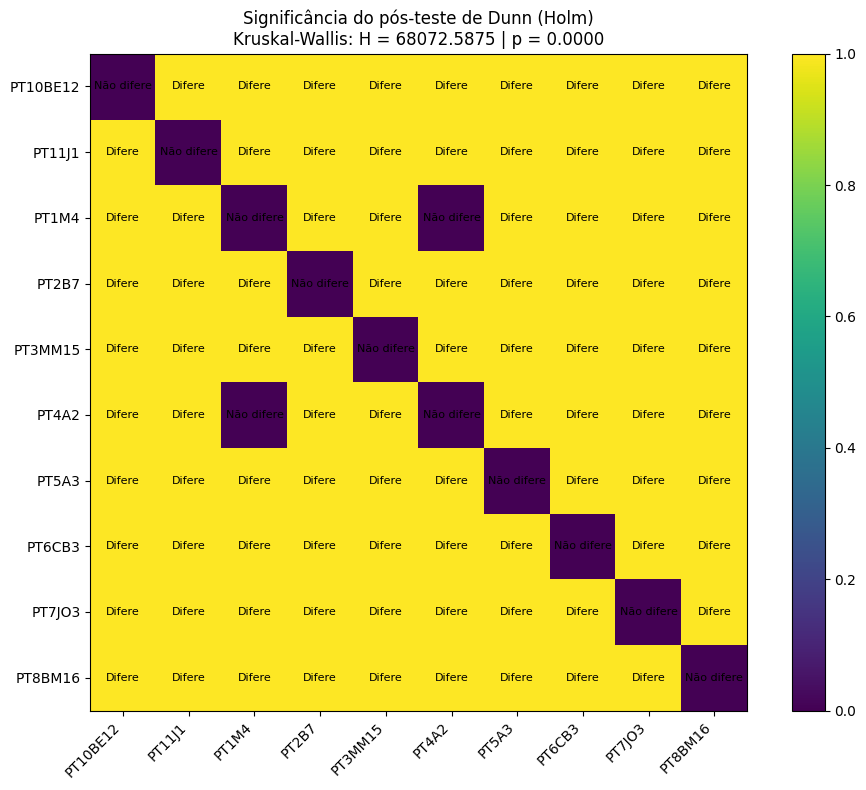

In [20]:
# Matriz binária de significância
significancia = (dunn < 0.05).astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(significancia.values)

ax.set_xticks(np.arange(len(significancia.columns)))
ax.set_yticks(np.arange(len(significancia.index)))
ax.set_xticklabels(significancia.columns, rotation=45, ha="right")
ax.set_yticklabels(significancia.index)

for i in range(len(significancia.index)):
    for j in range(len(significancia.columns)):
        texto = "Difere" if significancia.iloc[i, j] == 1 else "Não difere"
        ax.text(j, i, texto, ha="center", va="center", fontsize=8)

plt.title(
    f"Significância do pós-teste de Dunn (Holm)\n"
    f"Kruskal-Wallis: H = {estatistica:.4f} | p = {p_valor:.4f}"
)
plt.colorbar(im)
plt.tight_layout()
plt.show()